In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\aadhi\Desktop\Projects\Fake_News_Detection\data\processed\preprocessed_data.csv")
df

,text,label,cleaned_text
0,"Donald Trump s White House is in chaos, and th...",0,donald trump white house chaos trying cover ru...
1,Now that Donald Trump is the presumptive GOP n...,0,donald trump presumptive gop nominee time reme...
2,Mike Pence is a huge homophobe. He supports ex...,0,mike penny huge homophobe support exgay conver...
3,SAN FRANCISCO (Reuters) - California Attorney ...,1,san francisco reuters california attorney gene...
4,Twisted reasoning is all that comes from Pelos...,0,twisted reasoning come pelosi day especially p...
...,...,...,...
44183,ABUJA (Reuters) - The United States has formal...,1,abuja reuters united state formally agreed sel...
44184,Tune in to the Alternate Current Radio Network...,0,tune alternate current radio network acr anoth...
44185,I m convinced the Freedom From Religion group...,0,convinced freedom religion group atheist get e...
44186,WASHINGTON (Reuters) - The Republican tax plan...,1,washington reuters republican tax plan unveile...


In [2]:
x = df['cleaned_text']
y = df['label']

In [3]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2), min_df=5, max_df=0.7)

x_train_vec = tfidf.fit_transform(x_train)
x_test_vec = tfidf.transform(x_test)

In [5]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(x_train_vec, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [6]:
y_pred = svm_model.predict(x_test_vec)

In [13]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))

Accuracy: 0.9957003847024214

               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4555
           1       0.99      1.00      1.00      4283

    accuracy                           1.00      8838
   macro avg       1.00      1.00      1.00      8838
weighted avg       1.00      1.00      1.00      8838



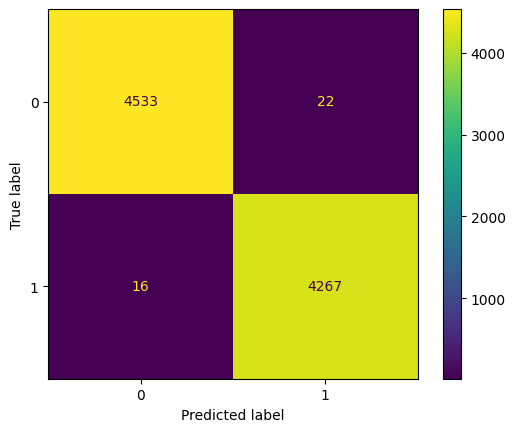

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [15]:
import joblib

joblib.dump(svm_model, r"C:\Users\aadhi\Desktop\Projects\Fake_News_Detection\models\svm_model.pkl")
joblib.dump(tfidf, r"C:\Users\aadhi\Desktop\Projects\Fake_News_Detection\models\tfidf_vectorizer.pkl")

['C:\\Users\\aadhi\\Desktop\\Projects\\Fake_News_Detection\\models\\tfidf_vectorizer.pkl']

In [17]:
from src.predict import predict_news

text = "Breaking: Government secretly approves new alien technology program"

predict_news(text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aadhi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aadhi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


'FAKE'

In [24]:
print(predict_news(""))
print(predict_news("🔥🔥 shocking truth 🔥🔥"))
print(predict_news("The US military is deploying three more warships and roughly 2,500 more marines to the Middle East, AP quoted an official as saying. One US official confirmed Friday that the USS Boxer and two other amphibious assault ships."))
print(predict_news("DUBAI (Reuters) - Eight women and two children from the same Yemeni family were killed when an air strike by forces of the Saudi-led coalition involved in the country s three-year-old war hit a wedding party, residents said on Monday. The 10 people were returning on Sunday evening from a wedding in Marib province, an area east of the capital Sanaa held by the Iran-allied Houthi group, when their vehicle was struck, the sources said. A spokesman for the coalition, which denies targeting civilians and says that every report of an attack is investigated, did not respond to an email requesting comment.  The residents said the victims, all female, were part of the same family, but gave no further details on their ages or if anyone else was traveling with them. The coalition has been conducting regular air strikes in Houthi-held areas as part of a campaign to restore President Abd-Rabbu Mansour Hadi to power. The United Nations says that more than 60,000 people have been killed or wounded in the conflict, which also displaced more than two million and triggered a cholera epidemic that has infected about one million people."))

FAKE
FAKE
FAKE
REAL
